In [3]:
import requests
import pandas as pd


res = requests.get(
    "https://api.exchange.coinbase.com/products",
)

target_ids = []
for product in res.json():
    if product["quote_currency"] == "USD":
        stats = requests.get(
            f"https://api.exchange.coinbase.com/products/{product['id']}/stats"
        ).json()
        if (
            "high" in stats
            and ((float(stats["high"]) + float(stats["low"])) / 2)
            * float(stats["volume_30day"])
            > 1000000
        ):
            target_ids.append(product["id"])

In [4]:
def get_ohlc(pair):
    url = f"https://api.exchange.coinbase.com/products/{pair}/candles?granularity=86400"
    candles = requests.get(url).json()

    df = pd.DataFrame(
        candles, columns=["date", "low", "high", "open", "close", "volume"]
    )
    df.index = pd.to_datetime(df["date"], unit="s")
    df = df.drop("date", axis=1)
    return df.sort_index()

In [5]:
price_data = {}
for pair in target_ids:
    ohlc = get_ohlc(pair)
    if ohlc.shape[0] == 350:
        price_data[pair] = ohlc
    else:
        print(f"Insufficient data for {pair}")

Insufficient data for GIGA-USD
Insufficient data for WIF-USD
Insufficient data for TURBO-USD
Insufficient data for SHDW-USD
Insufficient data for MOBILE-USD
Insufficient data for RENDER-USD
Insufficient data for KARRAT-USD
Insufficient data for ME-USD
Insufficient data for AKT-USD
Insufficient data for DRIFT-USD
Insufficient data for IO-USD
Insufficient data for SD-USD
Insufficient data for OMNI-USD
Insufficient data for NEON-USD
Insufficient data for TNSR-USD
Insufficient data for SWELL-USD
Insufficient data for POL-USD
Insufficient data for CORECHAIN-USD
Insufficient data for ARKM-USD
Insufficient data for ALEO-USD
Insufficient data for MOVE-USD
Insufficient data for BLAST-USD
Insufficient data for PEPE-USD
Insufficient data for PIRATE-USD
Insufficient data for TRUMP-USD
Insufficient data for SAFE-USD
Insufficient data for STRK-USD
Insufficient data for FLOKI-USD
Insufficient data for EIGEN-USD
Insufficient data for G-USD
Insufficient data for A8-USD
Insufficient data for WELL-USD
In

In [6]:
volume = {}
for pair, df in price_data.items():
    volume[pair] = (df["close"] * df["volume"]).sum()
volume_norm = pd.Series(volume).drop("USDT-USD").sort_values(ascending=False)

In [7]:
PF_SIZE = 20

In [8]:
pf = volume_norm.head(PF_SIZE)
pf_close_data = {}
for pair in pf.index:
    pf_close_data[pair] = price_data[pair]["close"]
pf_close = pd.DataFrame(pf_close_data)
pf_close

,BTC-USD,ETH-USD,SOL-USD,XRP-USD,DOGE-USD,SHIB-USD,BONK-USD,SUI-USD,HBAR-USD,LINK-USD,XLM-USD,AVAX-USD,ADA-USD,JASMY-USD,FET-USD,ONDO-USD,LTC-USD,RNDR-USD,INJ-USD,SEI-USD
date,,,,,,,,,,,,,,,,,,,,
2024-02-12,49941.81,2661.03,111.70,0.5317,0.08226,0.000010,0.000013,1.7621,0.07966,20.481,0.113171,40.99,0.5595,0.00590,0.6680,0.24277,72.85,4.8027,36.907,0.7570
2024-02-13,49725.36,2641.63,112.55,0.5248,0.08110,0.000009,0.000013,1.8580,0.08145,19.879,0.111004,39.75,0.5452,0.00596,0.6678,0.24964,69.00,4.9001,34.780,0.7554
2024-02-14,51858.59,2777.56,117.14,0.5384,0.08557,0.000010,0.000014,1.9081,0.08258,20.262,0.114489,42.25,0.5776,0.00618,0.6822,0.28704,69.90,5.0113,35.489,0.8815
2024-02-15,51934.29,2825.94,113.62,0.5627,0.08538,0.000010,0.000014,1.8651,0.08294,19.951,0.116829,41.59,0.6094,0.00637,0.6539,0.26060,69.84,5.3027,34.163,0.9308
2024-02-16,52162.64,2803.89,110.41,0.5647,0.08597,0.000010,0.000013,1.8091,0.08558,19.566,0.115531,40.28,0.5992,0.00633,0.7074,0.26190,70.64,5.2918,34.625,0.9345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-22,103667.11,3241.35,257.23,3.1792,0.36255,0.000020,0.000032,4.4684,0.32589,25.275,0.428399,36.78,0.9821,0.02677,1.2793,1.28930,115.31,7.0469,21.456,0.3468
2025-01-23,103926.36,3338.67,253.12,3.1200,0.35218,0.000020,0.000031,4.3047,0.32810,25.663,0.430968,35.56,0.9864,0.02704,1.2454,1.35413,116.42,7.0768,20.839,0.3424
2025-01-24,104850.27,3309.72,253.37,3.1009,0.35086,0.000020,0.000030,4.2024,0.32696,25.188,0.430933,35.33,0.9714,0.02694,1.2261,1.40402,118.72,6.8804,20.737,0.3400


In [34]:
pf_returns = pf_close.pct_change().iloc[1:-180]
pf_returns

,BTC-USD,ETH-USD,SOL-USD,XRP-USD,DOGE-USD,SHIB-USD,BONK-USD,SUI-USD,HBAR-USD,LINK-USD,XLM-USD,AVAX-USD,ADA-USD,JASMY-USD,FET-USD,ONDO-USD,LTC-USD,RNDR-USD,INJ-USD,SEI-USD
date,,,,,,,,,,,,,,,,,,,,
2024-02-13,-0.004334,-0.007290,0.007610,-0.012977,-0.014102,-0.015593,-0.049280,0.054424,0.022470,-0.029393,-0.019148,-0.030251,-0.025559,0.010169,-0.000299,0.028298,-0.052848,0.020280,-0.057631,-0.002114
2024-02-14,0.042900,0.051457,0.040782,0.025915,0.055117,0.030623,0.141946,0.026964,0.013874,0.019267,0.031395,0.062893,0.059428,0.036913,0.021563,0.149816,0.013043,0.022693,0.020385,0.166931
2024-02-15,0.001460,0.017418,-0.030050,0.045134,-0.002220,0.011270,-0.027933,-0.022536,0.004359,-0.015349,0.020439,-0.015621,0.055055,0.030744,-0.041483,-0.092113,-0.000858,0.058149,-0.037364,0.055927
2024-02-16,0.004397,-0.007803,-0.028252,0.003554,0.006910,0.001013,-0.043822,-0.030025,0.031830,-0.019297,-0.011110,-0.031498,-0.016738,-0.006279,0.081817,0.004988,0.011455,-0.002056,0.013523,0.003975
2024-02-17,-0.009517,-0.006084,-0.013223,-0.026386,-0.027684,-0.025304,-0.035312,-0.022332,-0.023837,0.024123,-0.011616,-0.012661,0.017523,-0.020537,0.113656,-0.037953,-0.009060,0.072414,0.093285,-0.029213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-26,0.032353,0.031708,0.065417,0.006672,0.071634,0.034777,0.059585,0.049873,0.036975,0.045999,0.009178,0.054699,0.057273,0.043165,0.069734,0.050668,0.036628,0.104676,0.083505,0.048128
2024-07-27,-0.000363,-0.007847,0.002731,-0.012593,-0.020344,0.003538,-0.012225,-0.003683,0.004384,0.001404,-0.016599,-0.024365,0.000240,0.103448,-0.005153,-0.017978,0.000280,-0.044219,-0.018986,-0.017186
2024-07-28,0.005079,0.006380,0.007300,0.009230,-0.010726,-0.012926,-0.009194,-0.044365,-0.016587,-0.018009,-0.011467,-0.022476,-0.023964,-0.008437,-0.022287,0.008742,-0.003645,-0.033181,-0.042973,-0.038798


In [ ]:
import numpy as np
import pandas as pd
import cvxpy as cp

# Compute covariance matrix
cov_matrix = pf_returns.cov()

# Define optimization problem
weights = cp.Variable(len(pf_returns.columns))
constraints = [cp.sum(weights) == 1, weights >= 0]  # Long-only portfolio
objective = cp.Minimize(cp.quad_form(weights, cov_matrix))  # Minimize variance
problem = cp.Problem(objective, constraints)

# Solve the problem
problem.solve()

# Optimal weights
optimal_weights = weights.value
weight_series = (
    pd.Series(optimal_weights, index=pf_returns.columns)
    .astype(float)
    .sort_values(ascending=False)
)
weight_series[weight_series > 0.0001]

BTC-USD     0.652740
XRP-USD     0.168567
LTC-USD     0.090581
SUI-USD     0.087299
ONDO-USD    0.000813
dtype: float64

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

RISK_FREE_RATE = 0.05
MAX_PORTS = 10000
MAX_WEIGHT = 1.05


def pf_generator(rets, cov_matrix):
    port_rets = []
    port_risks = []
    port_sharpes = []
    port_weights = []
    max_sharpe = 0
    for _ in range(MAX_PORTS):
        weights = np.random.uniform(0, MAX_WEIGHT, len(rets))
        weights /= np.sum(weights)  # Normalize weights to 1
        if any(weights > MAX_WEIGHT):
            continue
        port_weights.append(weights)
        port_ret = np.dot(weights, rets)
        port_rets.append(port_ret)
        port_risk = np.sqrt(weights.T @ cov_matrix @ weights)
        port_risks.append(port_risk)
        port_sharpe = (port_ret - RISK_FREE_RATE) / port_risk
        max_sharpe = max(max_sharpe, port_sharpe)
        if max_sharpe == port_sharpe:
            print(port_ret, port_risk, max_sharpe)
            print(pd.Series(weights, index=rets.index))
        port_sharpes.append(port_sharpe)
    port_rets = np.array(port_rets)
    port_risks = np.array(port_risks)
    plt.scatter(
        port_risks * 100.0,
        port_rets * 100.0,
        c=port_sharpes,
        cmap="viridis",
        alpha=0.75,
    )
    plt.xlabel("Risk (%)")
    plt.ylabel("Expected Returns (%)")
    plt.colorbar(label="Sharpe Ratio")
    plt.grid()
    return port_risks, port_rets, port_sharpes

In [12]:
rets = (1 + pf_returns).prod() - 1
rets
cov = pf_returns.cov()

0.22559025144456263 0.03803186123185984 4.616925013847815
BTC-USD      0.062015
ETH-USD      0.062541
SOL-USD      0.077375
XRP-USD      0.067670
DOGE-USD     0.048532
SHIB-USD     0.042746
BONK-USD     0.047440
SUI-USD      0.043202
HBAR-USD     0.000584
LINK-USD     0.085016
XLM-USD      0.039816
AVAX-USD     0.060936
ADA-USD      0.028891
JASMY-USD    0.028165
FET-USD      0.027924
ONDO-USD     0.008159
LTC-USD      0.045823
RNDR-USD     0.085843
INJ-USD      0.073981
SEI-USD      0.063344
dtype: float64
0.627568073902005 0.04033450433194394 14.319453863837003
BTC-USD      0.089976
ETH-USD      0.028846
SOL-USD      0.015371
XRP-USD      0.014930
DOGE-USD     0.003259
SHIB-USD     0.031464
BONK-USD     0.078879
SUI-USD      0.035423
HBAR-USD     0.056521
LINK-USD     0.034258
XLM-USD      0.046672
AVAX-USD     0.082502
ADA-USD      0.005826
JASMY-USD    0.063553
FET-USD      0.088052
ONDO-USD     0.079818
LTC-USD      0.095939
RNDR-USD     0.085045
INJ-USD      0.045894
SEI-USD     

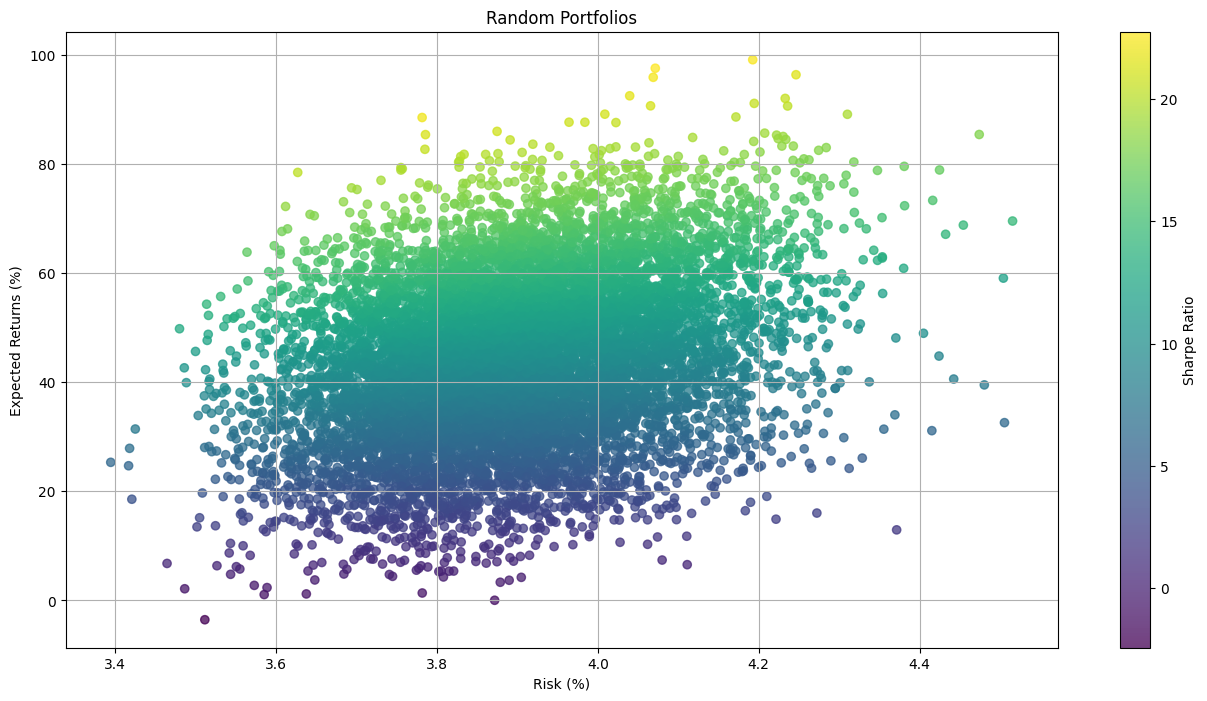

In [13]:
plt.figure(figsize=(16, 8))
plt.title("Random Portfolios")
port_risks, port_rets, port_sharpes = pf_generator(rets, cov)
plt.show()

In [ ]:
# Equal-weighted portfolio useful for matrix operations
equal_weights = np.ones(len(rets))

# Min variance weights
inv_cov_matrix = np.linalg.pinv(cov)
min_risk_vect = equal_weights @ inv_cov_matrix
expect_ret_vect = inv_cov_matrix @ rets
# Minimum variance portfolio
# Weights are normalized to sum to 1, and risk to std deviation.
mvp_weights = min_risk_vect / np.sum(min_risk_vect)
mvp_ret = mvp_weights @ rets
mvp_risk = np.sqrt(mvp_weights.T @ cov @ mvp_weights)
# Tangency portfolio
tan_weights = expect_ret_vect / np.sum(expect_ret_vect)
tan_ret = tan_weights @ rets
tan_risk = np.sqrt(tan_weights.T @ cov @ tan_weights)
summary_data = {
    "Asset": rets.index,
    "MVP Weights": mvp_weights,
    "TAN Weights": tan_weights,
}
print(f"mvp_ret: {mvp_ret * 100:0.02f}%, mvp_risk {mvp_risk * 100:0.02f}%")
print(f"tan_ret: {tan_ret * 100:0.02f}%, tan_risk {tan_risk * 100:0.02f}%")
summary_df = pd.DataFrame(summary_data)
summary_df.T

mvp_ret: 11.82%, mvp_risk 2.12%
tan_ret: 2897.05%, tan_risk 33.22%


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
Asset,BTC-USD,ETH-USD,SOL-USD,XRP-USD,DOGE-USD,SHIB-USD,BONK-USD,SUI-USD,HBAR-USD,LINK-USD,XLM-USD,AVAX-USD,ADA-USD,JASMY-USD,FET-USD,ONDO-USD,LTC-USD,RNDR-USD,INJ-USD,SEI-USD
MVP Weights,1.063739,0.005615,-0.045675,0.077924,-0.276456,0.002354,-0.070678,0.140053,0.016495,0.114481,0.108192,-0.121124,-0.038267,-0.018753,-0.022838,0.04232,0.10521,0.008341,0.008998,-0.099929
TAN Weights,1.531076,-0.69558,5.376137,6.111798,-1.799215,0.982911,0.474154,-2.264854,-0.924201,-3.43645,-3.431245,-2.38651,-4.933111,2.004858,0.585298,3.362601,1.824415,-0.741158,0.191315,-0.832239


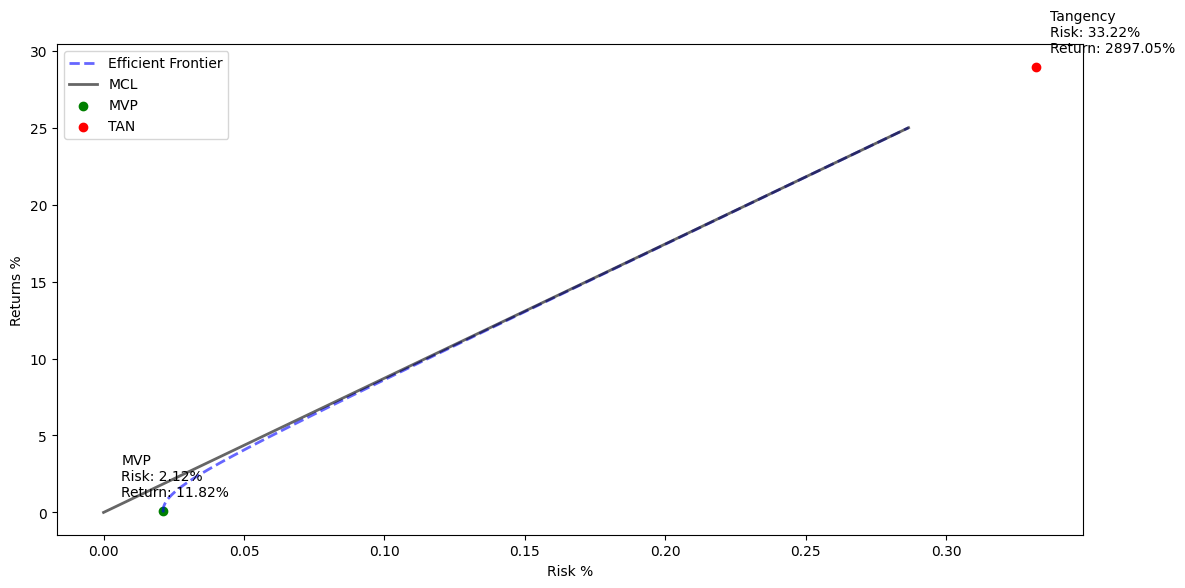

In [ ]:
MAX_RETS = 25
TEN_BASIS_POINTS = 0.0001 * 10

c = np.sum(equal_weights * min_risk_vect)  # Constant term
b = np.sum(rets * min_risk_vect)  # Linear term
a = np.sum(rets * expect_ret_vect)  # Quadratic term
utility_func = (a * c) + (-(b**2))  # U(X) to penalize risk
# The frontier curve & MCL, scaled by utility function
exp_rets = np.arange(0, MAX_RETS, TEN_BASIS_POINTS)
ports_risk_frontier = np.sqrt(
    ((c * (exp_rets**2)) - (2 * b * exp_rets) + a) / utility_func
)
mcl_vector = exp_rets * (1 / np.sqrt(a))
plt.figure(figsize=(12, 6))
plt.plot(
    ports_risk_frontier,
    exp_rets,
    linestyle="--",
    color="blue",
    label="Efficient Frontier",
    linewidth=2,
    alpha=0.6,
)
plt.plot(
    mcl_vector,
    exp_rets,
    label="MCL",
    linewidth=2,
    alpha=0.6,
    color="black",
)
plt.scatter(mvp_risk, mvp_ret, color="green", label="MVP")
plt.annotate(
    f"MVP\nRisk: {mvp_risk * 100:.2f}%\nReturn: {mvp_ret * 100:.2f}%",
    (mvp_risk, mvp_ret),
    textcoords="offset points",
    xytext=(-30, 10),
)
plt.scatter(tan_risk, tan_ret, color="red", label="TAN")
plt.annotate(
    f"Tangency\nRisk: {tan_risk * 100:.2f}%\nReturn: {tan_ret * 100:.2f}%",
    (tan_risk, tan_ret),
    textcoords="offset points",
    xytext=(10, 10),
)
plt.legend(loc="upper left", fontsize=10)
plt.xlabel("Risk %")
plt.ylabel("Returns %")
plt.tight_layout()
plt.show()

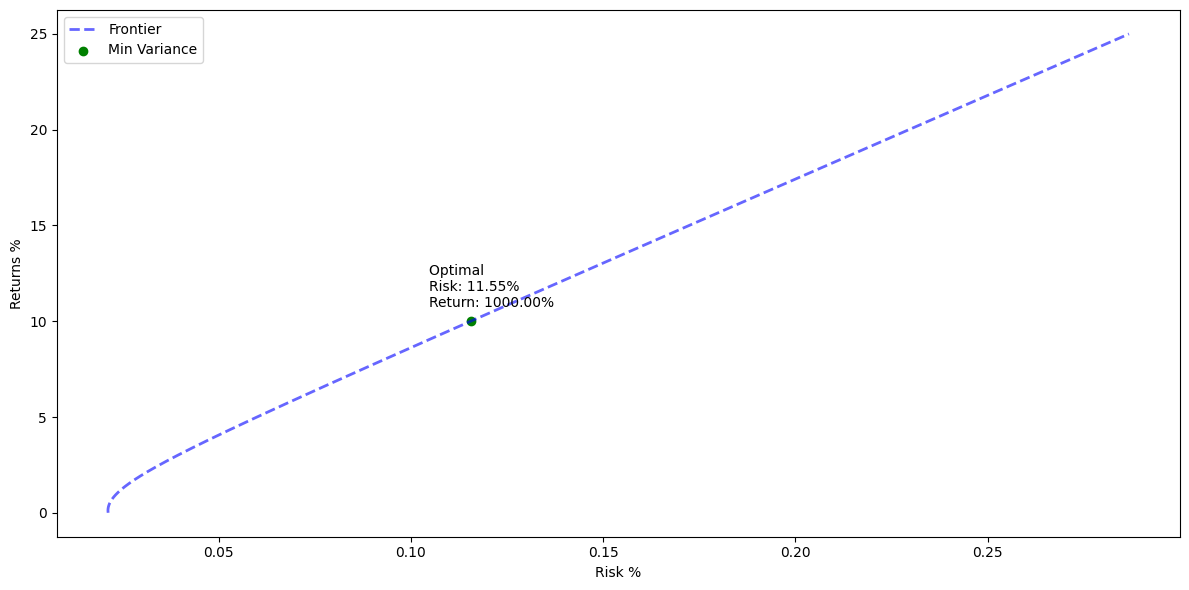

[ 1.22380064 -0.2345419   1.81127714  2.14450577 -0.79799604  0.33819128
  0.11592494 -0.68361963 -0.30569003 -1.10170077 -1.10405331 -0.89701121
 -1.71473499  0.67432671  0.18544643  1.17950473  0.69403193 -0.24835955
  0.07144074 -0.35074289]


In [ ]:
TARGET_RET = 10

pt_port = None
opt_risk = None
opt_ret = None
mvp_weights = (a - (b * TARGET_RET)) / utility_func
tan_weights = ((c * TARGET_RET) - b) / utility_func
opt_port_weights = (mvp_weights * min_risk_vect) + (tan_weights * expect_ret_vect)
opt_ret = np.sum(opt_port_weights * rets)
opt_risk = np.sqrt(((c * (opt_ret**2)) - (2 * b * opt_ret) + a) / utility_func)
plt.figure(figsize=(12, 6))
plt.plot(
    ports_risk_frontier,
    exp_rets,
    linestyle="--",
    color="blue",
    label="Frontier",
    linewidth=2,
    alpha=0.6,
)
plt.scatter(opt_risk, opt_ret, color="green", label="Min Variance")
plt.annotate(
    f"Optimal \nRisk: {opt_risk * 100:.2f}%\nReturn: {opt_ret * 100:.2f}%",
    (opt_risk, opt_ret),
    textcoords="offset points",
    xytext=(-30, 10),
)
plt.legend(loc="upper left", fontsize=10)
plt.xlabel("Risk %")
plt.ylabel("Returns %")
plt.tight_layout()
plt.show()
print(opt_port_weights)